# Customer Churn Prediction System Using Predictive Analytics and Machine Learning

## Import Libraries

In this section, we import all the libraries required for data manipulation, visualization, machine learning, and model evaluation.

In [218]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Save model
import joblib

# Display plots nicely
plt.style.use("ggplot")
%matplotlib inline

import os

def save_plot(filename):
    """
    Save the current matplotlib figure to the images folder.
    """
    save_path = os.path.join("..", "images", filename)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")


# Load the Dataset

The IBM Telco Customer Churn dataset is loaded from the raw data folder into a Pandas DataFrame for further analysis.

In [219]:
df = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


# Understanding the Dataset

Before performing data preprocessing or building machine learning models, it is important to understand the structure of the dataset. This includes checking the number of rows and columns, examining the data types, identifying missing values, and exploring the available features.

In [220]:
# Display the number of rows and columns
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (7043, 33)


In [221]:
# Display all column names
print(df.columns.tolist())

['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [222]:
# Display detailed information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [223]:
# Display summary statistics
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [224]:
# Check for missing values
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Churn Reason    5174
dtype: int64

In [225]:
# Check duplicate rows
print(f"Duplicate Rows: {df.duplicated().sum()}")

Duplicate Rows: 0


In [226]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Churn Reason    5174
dtype: int64

In [227]:
print(f"Duplicate Rows: {df.duplicated().sum()}")

Duplicate Rows: 0


### Observations

- The dataset contains 7,043 customer records and 33 attributes.
- Only the **Churn Reason** column contains missing values (5,174), which is expected because only churned customers have a recorded reason for leaving.
- No duplicate records were found in the dataset.
- The dataset contains a mix of numerical and categorical features suitable for machine learning.

In [228]:
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

1. CustomerID
2. Count
3. Country
4. State
5. City
6. Zip Code
7. Lat Long
8. Latitude
9. Longitude
10. Gender
11. Senior Citizen
12. Partner
13. Dependents
14. Tenure Months
15. Phone Service
16. Multiple Lines
17. Internet Service
18. Online Security
19. Online Backup
20. Device Protection
21. Tech Support
22. Streaming TV
23. Streaming Movies
24. Contract
25. Paperless Billing
26. Payment Method
27. Monthly Charges
28. Total Charges
29. Churn Label
30. Churn Value
31. Churn Score
32. CLTV
33. Churn Reason


In [229]:
df["CLTV"].describe()

count    7043.000000
mean     4400.295755
std      1183.057152
min      2003.000000
25%      3469.000000
50%      4527.000000
75%      5380.500000
max      6500.000000
Name: CLTV, dtype: float64

In [230]:
df["CLTV"].head()

0    3239
1    2701
2    5372
3    5003
4    5340
Name: CLTV, dtype: int64

In [231]:
df["Churn Score"].head()

0    86
1    67
2    86
3    84
4    89
Name: Churn Score, dtype: int64

# Data Cleaning

In this section, unnecessary columns that do not contribute to churn prediction or may cause data leakage are removed. This helps improve model reliability and reduces unnecessary complexity.

In [232]:
# Columns to remove

columns_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Score",
    "CLTV",
    "Churn Reason"
]

# Create cleaned dataset
df_clean = df.drop(columns=columns_to_drop)

# Display new shape
print("Original Shape :", df.shape)
print("Cleaned Shape  :", df_clean.shape)

Original Shape : (7043, 33)
Cleaned Shape  : (7043, 20)


In [233]:
df_clean.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


In [234]:
# Save the cleaned dataset
df_clean.to_csv("../data/cleaned/telco_customer_churn_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [235]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   str    
 1   Senior Citizen     7043 non-null   str    
 2   Partner            7043 non-null   str    
 3   Dependents         7043 non-null   str    
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   str    
 6   Multiple Lines     7043 non-null   str    
 7   Internet Service   7043 non-null   str    
 8   Online Security    7043 non-null   str    
 9   Online Backup      7043 non-null   str    
 10  Device Protection  7043 non-null   str    
 11  Tech Support       7043 non-null   str    
 12  Streaming TV       7043 non-null   str    
 13  Streaming Movies   7043 non-null   str    
 14  Contract           7043 non-null   str    
 15  Paperless Billing  7043 non-null   str    
 16  Payment Method     7043 non-null   

In [236]:
df_clean.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand customer behavior, identify patterns, and discover factors that influence customer churn.

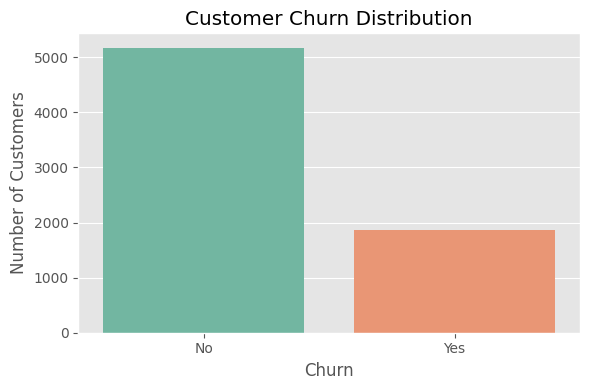

In [237]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df_clean,
    x="Churn Value",
    hue="Churn Value",
    palette="Set2",
    legend=False
)

ax.set_xticks([0, 1])
ax.set_xticklabels(["No", "Yes"])

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()

# Save the chart BEFORE showing it
save_plot("churn_distribution.png")

# Now display it
plt.show()

### Observation

The chart shows the distribution of customers who stayed and those who churned. This helps identify whether the dataset is balanced or imbalanced, which is important when training machine learning models.

## Customer Churn by Contract Type

This visualization compares customer churn across different contract types to identify which contract category has the highest number of customers leaving the service.

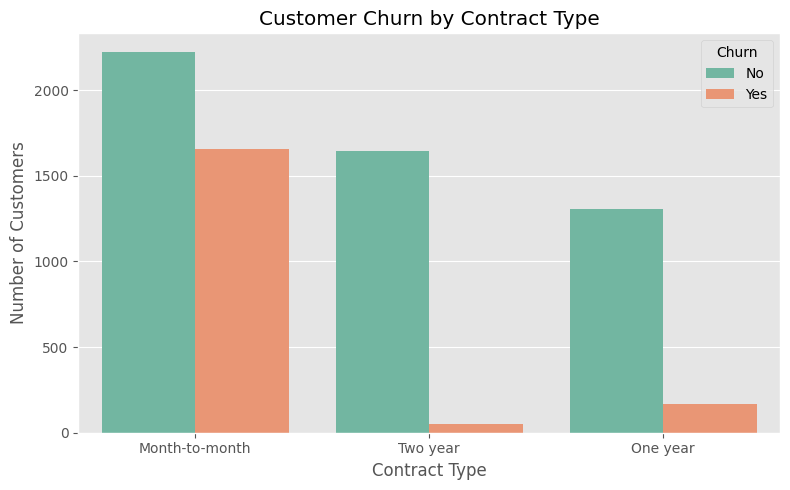

In [238]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="Contract",
    hue="Churn Value",
    palette="Set2"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.legend(title="Churn", labels=["No", "Yes"])

plt.tight_layout()

save_plot("contract_vs_churn.png")

plt.show()

### Observation

The chart shows that customers with month-to-month contracts have the highest churn compared to customers with one-year and two-year contracts. Customers with longer-term contracts are more likely to remain with the company, indicating that contract duration plays an important role in customer retention.

## Customer Churn by Internet Service

This visualization compares customer churn across different internet service types to understand whether the type of internet service influences customer retention.

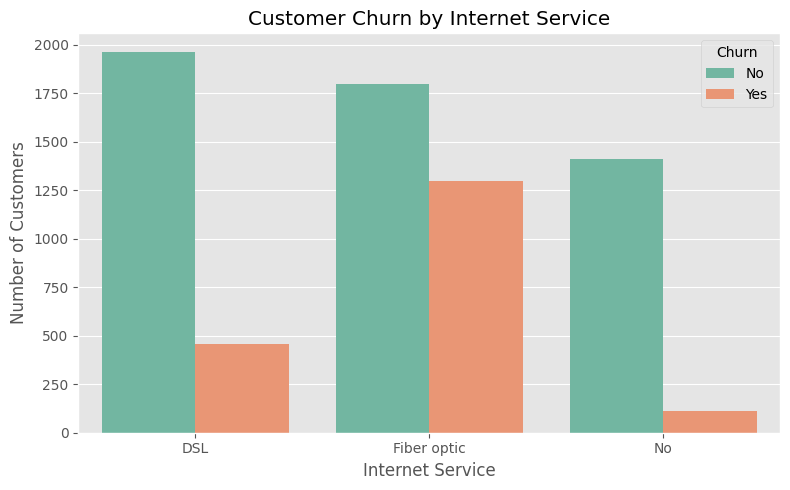

In [239]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="Internet Service",
    hue="Churn Value",
    palette="Set2"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.legend(title="Churn", labels=["No", "Yes"])

plt.tight_layout()

save_plot("internet_service_vs_churn.png")

plt.show()

### Observation

The chart shows that customers using **Fiber optic** internet service have the highest churn compared to customers using **DSL** or **No** internet service. Customers with DSL and no internet service exhibit relatively lower churn, suggesting that internet service type may influence customer retention.

## Customer Churn by Payment Method

This visualization compares customer churn across different payment methods to identify whether the payment method is associated with customer churn.

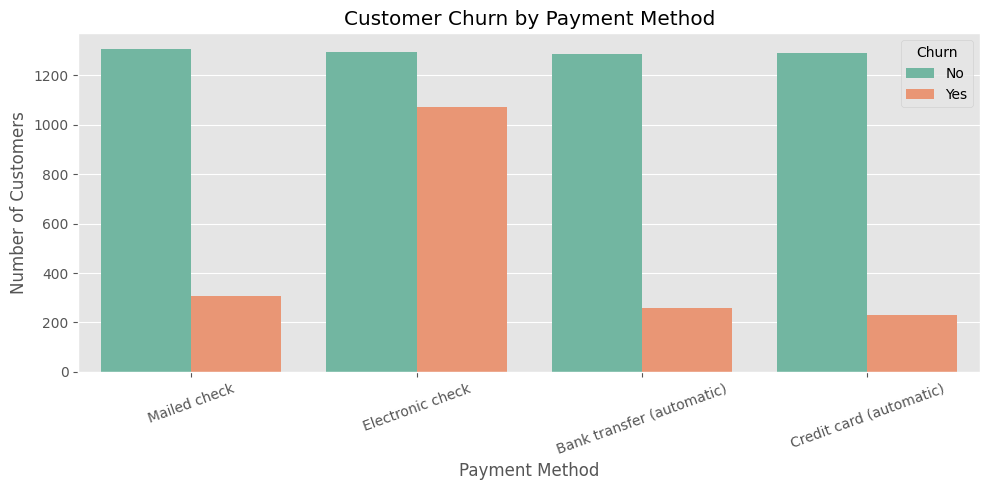

In [240]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df_clean,
    x="Payment Method",
    hue="Churn Value",
    palette="Set2"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.legend(title="Churn", labels=["No", "Yes"])

plt.xticks(rotation=20)

plt.tight_layout()

save_plot("payment_method_vs_churn.png")

plt.show()

### Observation

The chart shows that customers using **Electronic check** as their payment method have the highest churn compared to other payment methods. Customers using **Credit card (automatic)** and **Bank transfer (automatic)** have lower churn, suggesting that automatic payment methods may be associated with better customer retention.

## Customer Tenure Distribution by Churn

This visualization compares the distribution of customer tenure for churned and retained customers to understand whether the length of service influences customer churn.

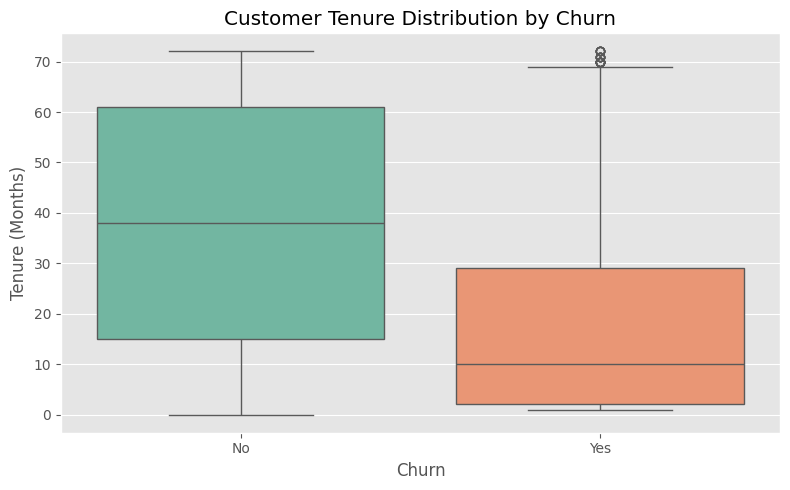

In [241]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Churn Value",
    y="Tenure Months",
    hue="Churn Value",
    palette="Set2",
    legend=False
)

plt.title("Customer Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.xticks([0, 1], ["No", "Yes"])

plt.tight_layout()

save_plot("tenure_distribution.png")

plt.show()

### Observation

The box plot shows that customers who churn generally have a much shorter tenure than customers who remain with the company. The median tenure of churned customers is significantly lower, indicating that customers are more likely to leave during the early months of their subscription.

## Monthly Charges by Churn

This visualization compares the distribution of monthly charges for churned and retained customers to examine whether monthly service charges influence customer churn.

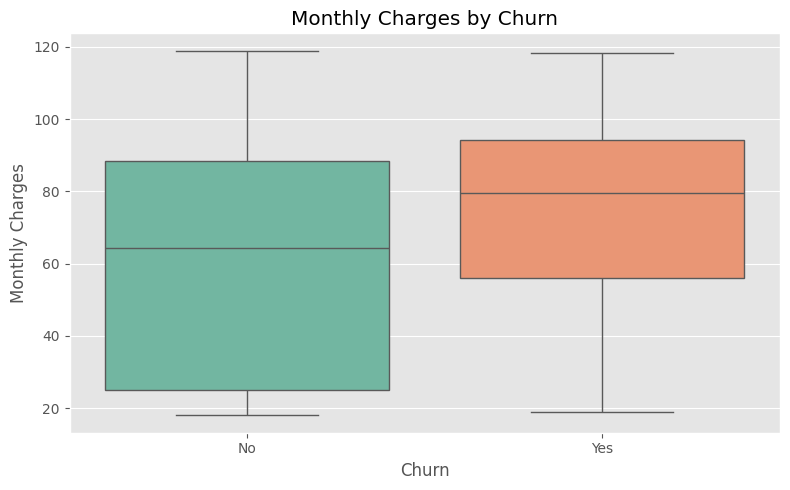

In [242]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Churn Value",
    y="Monthly Charges",
    hue="Churn Value",
    palette="Set2",
    legend=False
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.xticks([0, 1], ["No", "Yes"])

plt.tight_layout()

save_plot("monthly_charges_vs_churn.png")

plt.show()

### Observation

The box plot indicates that customers who churn generally have higher monthly charges than customers who remain with the company. This suggests that higher service costs may contribute to customer churn.

## Correlation Heatmap

The correlation heatmap illustrates the relationships among numerical variables in the dataset, helping identify features that are positively or negatively correlated.

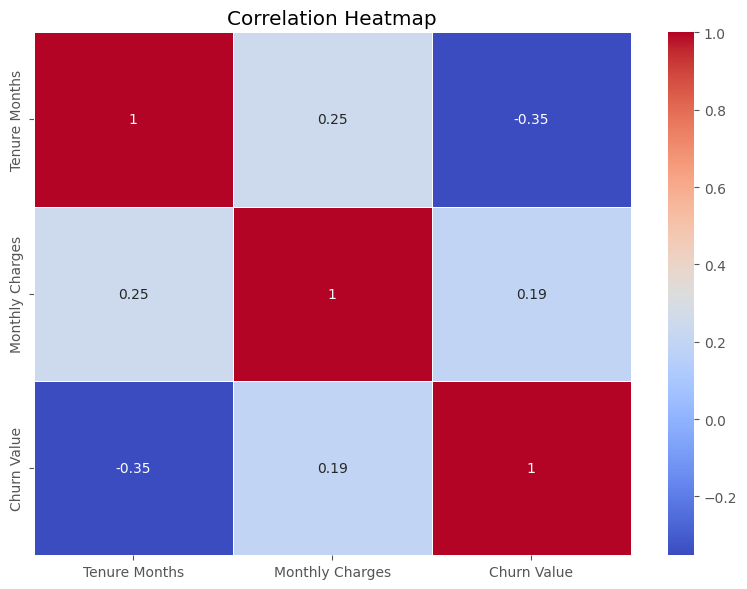

In [243]:
plt.figure(figsize=(8, 6))

numeric_df = df_clean.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()

save_plot("correlation_heatmap.png")

plt.show()

### Observation

The correlation heatmap shows that **Tenure Months** has a moderate negative correlation with **Churn Value** (-0.35), indicating that customers with longer tenure are less likely to churn. **Monthly Charges** has a weak positive correlation (0.19) with churn, suggesting that higher monthly charges may slightly increase the likelihood of customer churn.

# Data Preprocessing

Machine learning algorithms require numerical input. In this section, categorical variables are converted into numerical values using Label Encoding.

In [244]:
# Convert Total Charges to numeric
df_clean["Total Charges"] = pd.to_numeric(
    df_clean["Total Charges"],
    errors="coerce"
)

# Check missing values created during conversion
print(df_clean["Total Charges"].isnull().sum())

11


In [245]:
# ==========================================
# Data Preprocessing
# ==========================================

from sklearn.preprocessing import LabelEncoder

# Create a copy of the cleaned dataset
df_encoded = df_clean.copy()

# -----------------------------
# Convert Total Charges to numeric
# -----------------------------
df_encoded["Total Charges"] = pd.to_numeric(
    df_encoded["Total Charges"],
    errors="coerce"
)

# Fill missing values with median
median_value = df_encoded["Total Charges"].median()
df_encoded["Total Charges"] = df_encoded["Total Charges"].fillna(median_value)

# -----------------------------
# Encode categorical variables
# -----------------------------
label_encoder = LabelEncoder()

categorical_columns = df_encoded.select_dtypes(
    include=["object", "string"]
).columns

for column in categorical_columns:
    df_encoded[column] = label_encoder.fit_transform(df_encoded[column])

# Display first few rows
df_encoded.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
1,0,0,0,1,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
2,0,0,0,1,8,1,2,1,0,0,2,0,2,2,0,1,2,99.65,820.50,1
3,0,0,1,1,28,1,2,1,0,0,2,2,2,2,0,1,2,104.80,3046.05,1
4,1,0,0,1,49,1,2,1,0,2,2,0,2,2,0,1,0,103.70,5036.30,1


In [246]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   int64  
 1   Senior Citizen     7043 non-null   int64  
 2   Partner            7043 non-null   int64  
 3   Dependents         7043 non-null   int64  
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   int64  
 6   Multiple Lines     7043 non-null   int64  
 7   Internet Service   7043 non-null   int64  
 8   Online Security    7043 non-null   int64  
 9   Online Backup      7043 non-null   int64  
 10  Device Protection  7043 non-null   int64  
 11  Tech Support       7043 non-null   int64  
 12  Streaming TV       7043 non-null   int64  
 13  Streaming Movies   7043 non-null   int64  
 14  Contract           7043 non-null   int64  
 15  Paperless Billing  7043 non-null   int64  
 16  Payment Method     7043 non-null   

In [247]:
# Features
X = df_encoded.drop("Churn Value", axis=1)

# Target
y = df_encoded["Churn Value"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (7043, 19)
Target Shape: (7043,)


In [248]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (5634, 19)
Testing Features : (1409, 19)
Training Labels  : (5634,)
Testing Labels   : (1409,)


In [249]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

numeric_columns = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

X_train_scaled[numeric_columns] = scaler.fit_transform(
    X_train[numeric_columns]
)

X_test_scaled[numeric_columns] = scaler.transform(
    X_test[numeric_columns]
)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


# Logistic Regression Model

Logistic Regression is a supervised machine learning algorithm commonly used for binary classification problems. In this project, it is used to predict whether a customer is likely to churn.

In [250]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Train the model
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_log = log_model.predict(X_test_scaled)

# Evaluate
print("===== Logistic Regression =====")
print(f"Accuracy : {accuracy_score(y_test, y_pred_log):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_log):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_log):.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_log))

===== Logistic Regression =====
Accuracy : 0.8034
Precision: 0.6431
Recall   : 0.5829
F1 Score : 0.6115

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.64      0.58      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



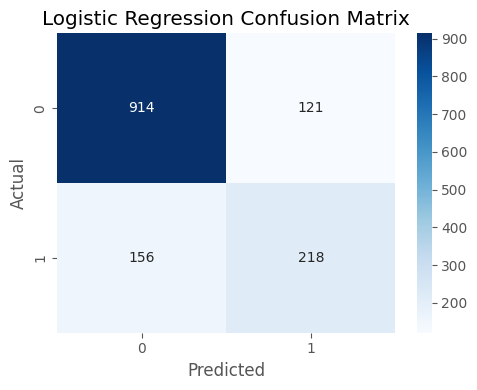

In [251]:
plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_log),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

save_plot("logistic_confusion_matrix.png")

plt.show()

### Observation

The Logistic Regression model achieved an accuracy of **80.34%**, indicating good overall performance in predicting customer churn. The model correctly classified most non-churning customers and was able to identify a reasonable number of churning customers. However, some churning customers were incorrectly classified as non-churning, suggesting room for improvement using more advanced machine learning models.

# Decision Tree Model

Decision Tree is a supervised machine learning algorithm that classifies data by creating a tree-like structure of decision rules. It is easy to interpret and can capture non-linear relationships in the data.

In [252]:
from sklearn.tree import DecisionTreeClassifier

# Train the model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print("===== Decision Tree =====")
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_dt):.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_dt))

===== Decision Tree =====
Accuracy : 0.7850
Precision: 0.5864
Recall   : 0.6444
F1 Score : 0.6140

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.84      0.85      1035
           1       0.59      0.64      0.61       374

    accuracy                           0.78      1409
   macro avg       0.73      0.74      0.73      1409
weighted avg       0.79      0.78      0.79      1409



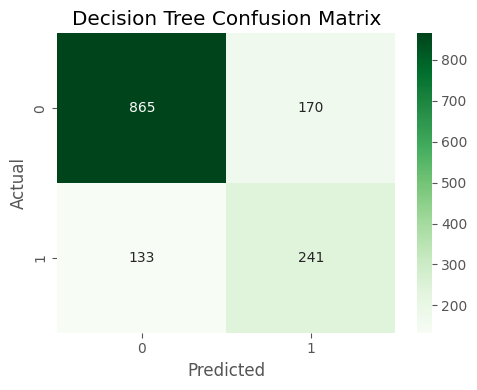

In [253]:
plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_dt),
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

save_plot("decision_tree_confusion_matrix.png")

plt.show()

### Observation

The Decision Tree model achieved an accuracy of **78.50%**. Although its overall accuracy is slightly lower than Logistic Regression, it achieved a higher recall, meaning it identified a greater number of customers who actually churned. This makes the model useful when minimizing missed churn cases is more important than maximizing overall accuracy.

# Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is widely used for classification problems due to its robustness and high performance.

In [254]:
from sklearn.ensemble import RandomForestClassifier

# Train the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("===== Random Forest =====")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_rf):.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))

===== Random Forest =====
Accuracy : 0.7949
Precision: 0.6393
Recall   : 0.5214
F1 Score : 0.5744

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



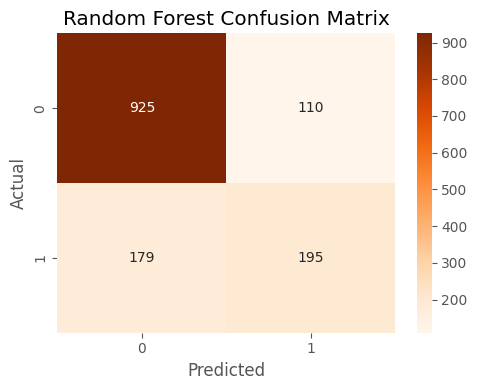

In [255]:
plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

save_plot("random_forest_confusion_matrix.png")

plt.show()

### Observation

The Random Forest model achieved an accuracy of **79.49%**. Although its overall accuracy is comparable to Logistic Regression, it achieved a lower recall and F1-score for predicting churned customers. In this project, Logistic Regression provided better overall performance and was selected as the final model.

# Model Comparison

The performance of all machine learning models is compared using accuracy, precision, recall, and F1-score to identify the best-performing model.

In [256]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8034,0.6431,0.5829,0.6115
1,Decision Tree,0.7850,0.5864,0.6444,0.6140
2,Random Forest,0.7949,0.6393,0.5214,0.5744


### Observation

Among the three machine learning models, **Logistic Regression** achieved the highest accuracy (**80.34%**) while maintaining a good balance between precision, recall, and F1-score. Therefore, Logistic Regression was selected as the final model for customer churn prediction.

# Saving the Best Model

The best-performing machine learning model is saved for future use and deployment.

In [257]:
import joblib

joblib.dump(log_model, "../models/customer_churn_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# Conclusion

This project successfully developed a customer churn prediction system using machine learning techniques. After preprocessing the data, performing exploratory data analysis, and evaluating multiple classification algorithms, Logistic Regression achieved the best overall performance with an accuracy of **80.34%**.

The analysis revealed that customers with month-to-month contracts, fiber optic internet service, electronic check payment methods, shorter tenure, and higher monthly charges were more likely to churn.

The developed model can assist organizations in identifying customers at risk of leaving and support proactive customer retention strategies.

# Feature Importance

Feature importance analysis identifies the most influential factors affecting customer churn. This helps understand which customer attributes contribute the most to churn prediction.

In [258]:
# Get feature importance from Random Forest

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
18,Total Charges,0.179892
17,Monthly Charges,0.173788
4,Tenure Months,0.155685
14,Contract,0.080227
8,Online Security,0.049891
16,Payment Method,0.049608
11,Tech Support,0.041774
3,Dependents,0.037298
0,Gender,0.027349
9,Online Backup,0.027084


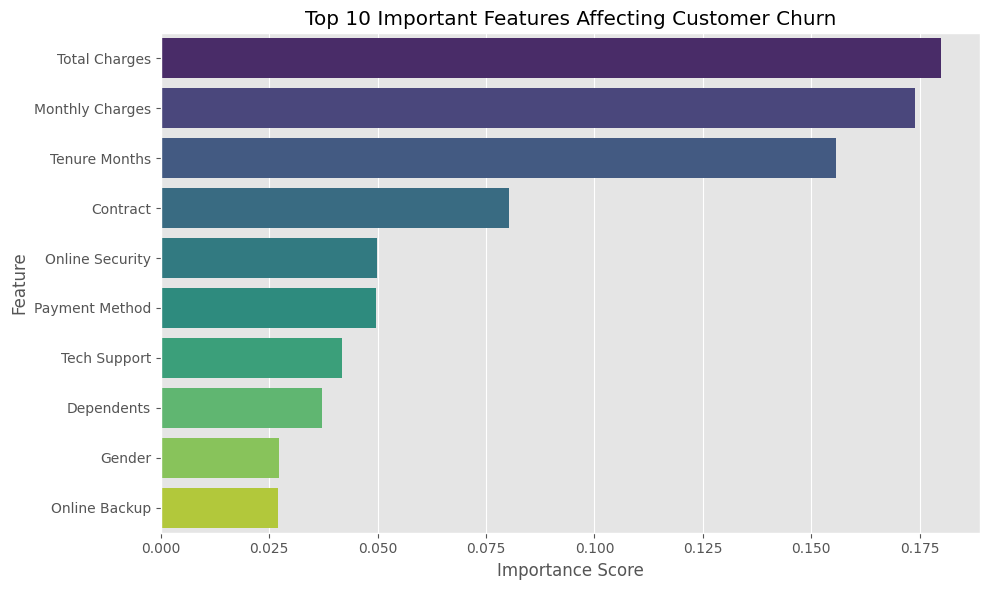

In [259]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    palette="viridis",
    hue="Feature",
    legend=False
)

plt.title("Top 10 Important Features Affecting Customer Churn")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()

save_plot("feature_importance.png")

plt.show()

### Observation

The Random Forest model identified **Total Charges**, **Monthly Charges**, **Tenure Months**, and **Contract** as the most important features for predicting customer churn. Features such as **Online Security**, **Payment Method**, and **Tech Support** also contributed to the predictions. These results provide insights into the factors that are most influential in the Random Forest model.

In [260]:
comparison.to_csv("../reports/model_comparison.csv", index=False)

print("Model comparison table saved successfully!")

Model comparison table saved successfully!


# Model Performance Comparison

This chart compares the accuracy of the machine learning models used in this project.

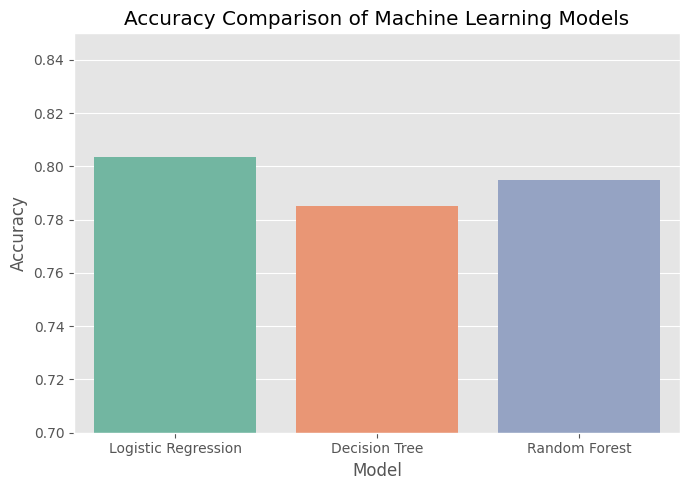

In [261]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="Set2",
    legend=False
)

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0.70, 0.85)

plt.tight_layout()

save_plot("model_accuracy_comparison.png")

plt.show()

### Observation

The comparison chart shows that **Logistic Regression** achieved the highest accuracy among the three machine learning models. Decision Tree and Random Forest also performed well but produced slightly lower accuracy. Therefore, Logistic Regression was selected as the final model for customer churn prediction.

# Saving Model and Scaler

The trained Logistic Regression model and the StandardScaler object are saved for future predictions in the Streamlit application.

In [262]:
import joblib

# Save model
joblib.dump(log_model, "../models/customer_churn_model.pkl")

# Save scaler
joblib.dump(scaler, "../models/scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [263]:
feature_names = X.columns.tolist()

joblib.dump(feature_names, "../models/feature_names.pkl")

print("Feature names saved!")

Feature names saved!


# Future Scope

The developed customer churn prediction system can be further enhanced by integrating additional machine learning algorithms, deploying the model as a web application, and using real-time customer data. Future improvements may also include automated retraining, advanced feature engineering, and integration with business intelligence platforms for continuous monitoring and decision support.

# Save Label Encoders

The label encoders used during preprocessing are saved so that the Streamlit application can encode user inputs in the same way as the training data.

In [264]:
from sklearn.preprocessing import LabelEncoder
import joblib

# Create a copy of the cleaned dataset
df_encoded = df_clean.copy()

# Dictionary to store encoders
label_encoders = {}

# Encode categorical columns
categorical_columns = df_encoded.select_dtypes(
    include=["object", "string"]
).columns

for column in categorical_columns:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column])
    label_encoders[column] = le

print("All categorical columns encoded successfully.")

All categorical columns encoded successfully.


In [265]:
joblib.dump(label_encoders, "../models/label_encoders.pkl")

print("Label encoders saved successfully!")

Label encoders saved successfully!


In [268]:
print(scaler.feature_names_in_)

['Tenure Months' 'Monthly Charges' 'Total Charges']
